In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\Divyani Singh\OneDrive\Desktop\Internshala DS Course\All_Courses\ML\Snapdeal_Project\Snapdeal_Cleaned.csv")
df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Timestamp                                      800 non-null    str  
 1   age                                            800 non-null    int64
 2   Gender                                         800 non-null    str  
 3   Purchase_Frequency                             800 non-null    str  
 4   Purchase_Categories                            800 non-null    str  
 5   Personalized_Recommendation_Frequency          800 non-null    str  
 6   Browsing_Frequency                             800 non-null    str  
 7   Product_Search_Method                          800 non-null    str  
 8   Search_Result_Exploration                      800 non-null    str  
 9   Customer_Reviews_Importance                    800 non-null    int64
 10  Add_to_Cart_B

In [4]:
#Segmentation of Customers based on Purchase Frequency-
print("Data under Purchase_Frequency:\n", df['Purchase_Frequency'].value_counts())

Data under Purchase_Frequency:
 Purchase_Frequency
Multiple times a week     166
Once a month              164
Once a week               161
Few times a month         157
Less than once a month    152
Name: count, dtype: int64


Purchase Frequency mapped to scores:
       Purchase_Frequency  Purchase_Frequency_Score
0            Once a week                         4
1           Once a month                         2
2  Multiple times a week                         5
3      Few times a month                         3
4           Once a month                         2
5  Multiple times a week                         5
6           Once a month                         2
7            Once a week                         4
8           Once a month                         2
9            Once a week                         4
Customer Segment Counts:
 Customer_Segment
Occasional  Shopper    352
At-Risk Customer       320
Frequent Buyer         128
Name: count, dtype: int64


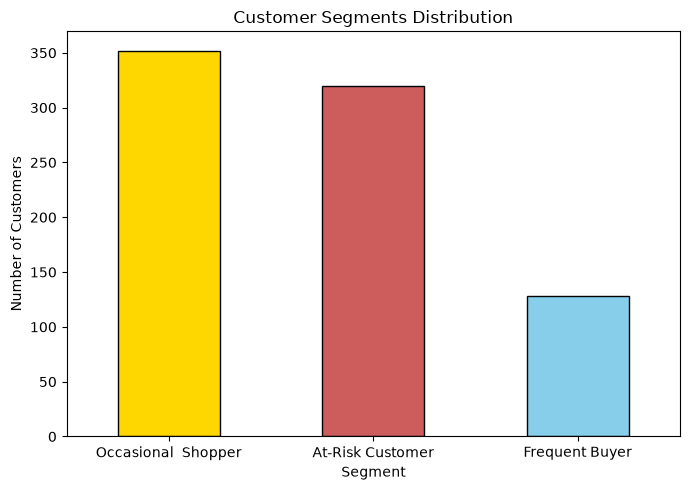

In [5]:
#Segmentation of Customers based on Purchase Frequency and Shopping Satisfaction-
frequency_order={
    'Less than once a month':1,
    'Once a month':2,
    'Few times a month':3,
    'Once a week':4,
    'Multiple times a week':5
}
df['Purchase_Frequency_Score']= df['Purchase_Frequency'].map(frequency_order)
print("Purchase Frequency mapped to scores:\n", df[['Purchase_Frequency', 'Purchase_Frequency_Score']].head(10))

#Creating Profiles ( At-Risk Customers, Frequent Buyers, Occasional Shopper)
def assignment_segment(row):
    freq=row['Purchase_Frequency_Score']
    satisfaction=row['Shopping_Satisfaction']

    if satisfaction <=2:
        return 'At-Risk Customer'
    elif freq>=4 and satisfaction>=4:
        return 'Frequent Buyer'
    else:
        return 'Occasional  Shopper'

df['Customer_Segment']=df.apply(assignment_segment, axis=1)

print("Customer Segment Counts:\n", df['Customer_Segment'].value_counts())


#Visualization-
plt.figure(figsize=(7,5))
colors= {'At-Risk Customer':'indianred', 'Occasional  Shopper':'gold', 'Frequent Buyer': 'skyblue'}
segment_counts=df['Customer_Segment'].value_counts()
segment_counts.plot(kind='bar', color=[colors[label] for label in segment_counts.index], edgecolor='black')
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Gender distribution within each segment:

Gender               Female  Male  Others  Prefer not to say
Customer_Segment                                            
At-Risk Customer         84    74      84                 78
Frequent Buyer           27    36      35                 30
Occasional  Shopper      90   103      73                 86
Average age per segment:

Customer_Segment
At-Risk Customer       36.2
Frequent Buyer         36.0
Occasional  Shopper    36.0
Name: age, dtype: float64
Cart Abandonment Factors by Segment:

Cart_Abandonment_Factors  Changed my mind or no longer need the item  \
Customer_Segment                                                       
At-Risk Customer                                                  80   
Frequent Buyer                                                    33   
Occasional  Shopper                                               78   

Cart_Abandonment_Factors  Found a better price elsewhere  High shipping costs  \
Customer_Segment    

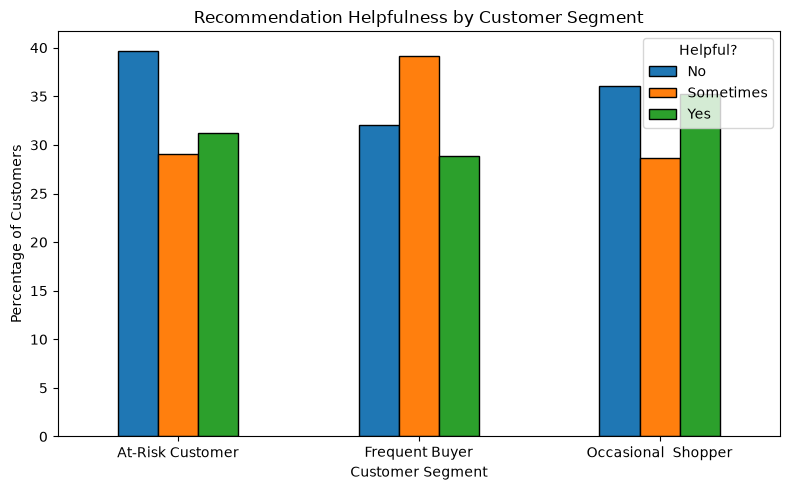

In [6]:
print("Gender distribution within each segment:\n")
print(pd.crosstab(df['Customer_Segment'], df['Gender']))

print("Average age per segment:\n")
print(df.groupby('Customer_Segment')['age'].mean().round(1))

print("Cart Abandonment Factors by Segment:\n")
print(pd.crosstab(df['Customer_Segment'], df['Cart_Abandonment_Factors']))

print("Cart Abandonment Factors by Segment (% within each segment):\n")
crosstab_pct = pd.crosstab(df['Customer_Segment'], df['Cart_Abandonment_Factors'], normalize='index').round(3) * 100
print(crosstab_pct)

print("Recommendation Helpfulness by Segment (% within each segment):\n")
rec_crosstab = pd.crosstab(df['Customer_Segment'], df['Recommendation_Helpfulness'], normalize='index').round(3) * 100
print(rec_crosstab)



plt.figure(figsize=(8,5))
rec_crosstab.plot(kind='bar', stacked=False, edgecolor='black', ax=plt.gca())
plt.title('Recommendation Helpfulness by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Helpful?')
plt.tight_layout()
plt.show()

In [7]:
cluster_features = df[['Purchase_Frequency_Score', 'Shopping_Satisfaction', 'Customer_Reviews_Importance', 'Rating_Accuracy ']]

print(cluster_features.describe())

       Purchase_Frequency_Score  Shopping_Satisfaction  \
count                800.000000             800.000000   
mean                   3.031250               2.988750   
std                    1.413425               1.407515   
min                    1.000000               1.000000   
25%                    2.000000               2.000000   
50%                    3.000000               3.000000   
75%                    4.000000               4.000000   
max                    5.000000               5.000000   

       Customer_Reviews_Importance  Rating_Accuracy   
count                   800.000000         800.00000  
mean                      2.988750           2.96375  
std                       1.400384           1.42565  
min                       1.000000           1.00000  
25%                       2.000000           2.00000  
50%                       3.000000           3.00000  
75%                       4.000000           4.00000  
max                       5.000000   

In [ ]:
# K-Means Clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

print("Scaled data sample (first 5 rows):\n", scaled_features[:5])

Scaled data sample (first 5 rows):
 [[ 0.68582057  0.00799781  0.72257522  0.02544291]
 [-0.73006706 -0.70291842 -1.42103482  1.42918988]
 [ 1.39376438  0.00799781 -0.70649814  0.02544291]
 [-0.02212324  1.42983026 -0.70649814  0.72731639]
 [-0.73006706 -1.41383464  1.43711189  0.02544291]]


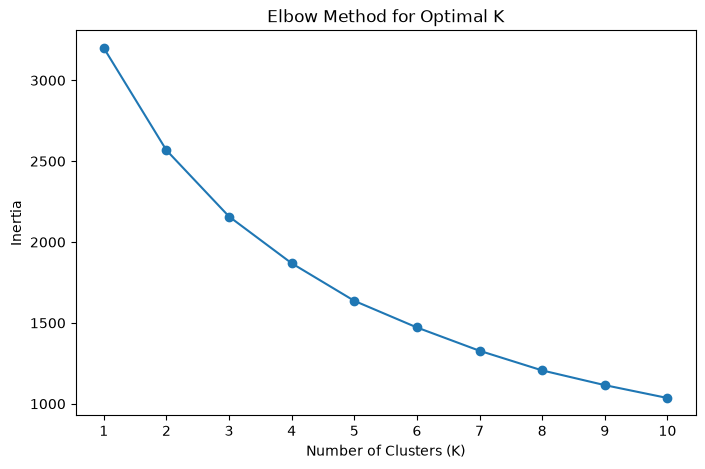

Number of customers per K-Means cluster:
 KMeans_Cluster
0    204
1    183
2    214
3    199
Name: count, dtype: int64
Average feature values per K-Means cluster:
                 Purchase_Frequency_Score  Shopping_Satisfaction  \
KMeans_Cluster                                                    
0                                   2.37                   2.92   
1                                   1.72                   3.17   
2                                   4.38                   3.25   
3                                   3.47                   2.61   

                Customer_Reviews_Importance  Rating_Accuracy   
KMeans_Cluster                                                 
0                                      4.24              4.03  
1                                      2.58              1.64  
2                                      3.41              1.99  
3                                      1.63              4.14  


In [9]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(scaled_features)

print("Number of customers per K-Means cluster:\n", df['KMeans_Cluster'].value_counts().sort_index())

cluster_profile = df.groupby('KMeans_Cluster')[['Purchase_Frequency_Score', 'Shopping_Satisfaction', 'Customer_Reviews_Importance', 'Rating_Accuracy ']].mean().round(2)

print("Average feature values per K-Means cluster:\n", cluster_profile)

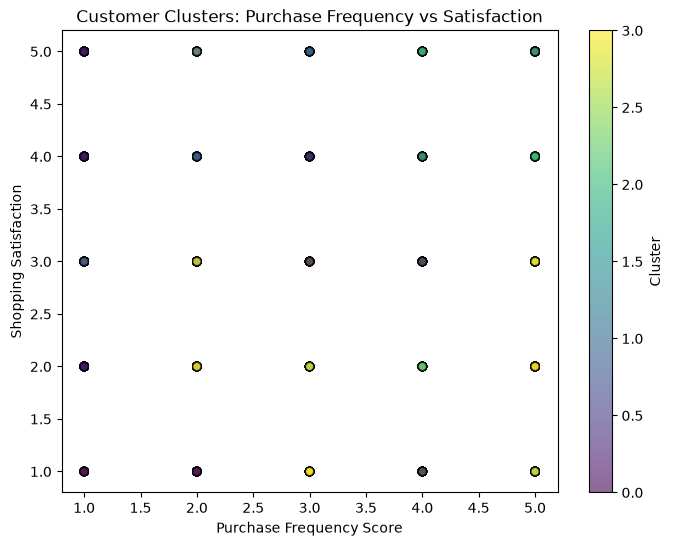

In [10]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['Purchase_Frequency_Score'], df['Shopping_Satisfaction'], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.6, edgecolor='black')
plt.title('Customer Clusters: Purchase Frequency vs Satisfaction')
plt.xlabel('Purchase Frequency Score')
plt.ylabel('Shopping Satisfaction')
plt.colorbar(scatter, label='Cluster')
plt.show()

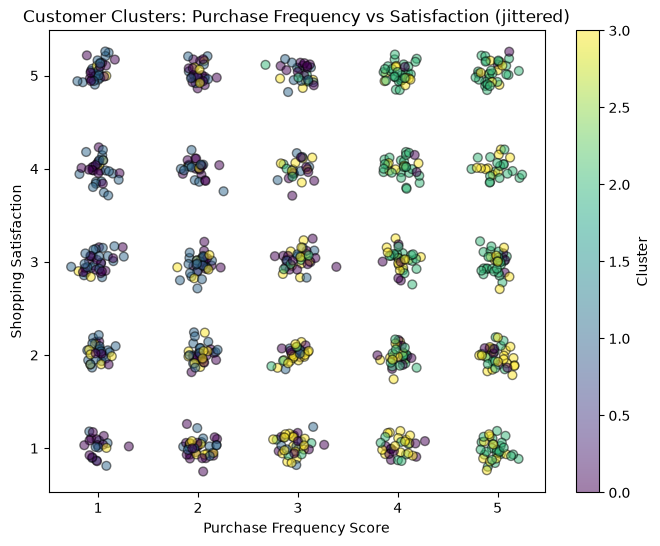

In [11]:
import numpy as np

np.random.seed(42)
jitter_x = df['Purchase_Frequency_Score'] + np.random.normal(0, 0.1, size=len(df))
jitter_y = df['Shopping_Satisfaction'] + np.random.normal(0, 0.1, size=len(df))

plt.figure(figsize=(8,6))
scatter = plt.scatter(jitter_x, jitter_y, c=df['KMeans_Cluster'], cmap='viridis', alpha=0.5, edgecolor='black', s=40)
plt.title('Customer Clusters: Purchase Frequency vs Satisfaction (jittered)')
plt.xlabel('Purchase Frequency Score')
plt.ylabel('Shopping Satisfaction')
plt.colorbar(scatter, label='Cluster')
plt.show()